# Глубокие автоэнкодеры на Fashion-MNIST

Датасет: `Fashion-MNIST`.

Фреймворк: `TensorFlow / Keras`.

Основные модели:

1. простой полносвязный автоэнкодер;
2. глубокий полносвязный автоэнкодер;
3. сверточный автоэнкодер для изображений.

## План занятия

| Этап | Содержание |
|---|---|
| 1 | Идея автоэнкодера |
| 2 | Загрузка и подготовка Fashion-MNIST |
| 3 | Простой dense autoencoder |
| 4 | Deep dense autoencoder |
| 5 | Convolutional autoencoder |
| 6 | Сравнение качества реконструкции |

Автоэнкодер состоит из двух частей:

$$
z = f_\theta(x),
$$

$$
\hat{x} = g_\phi(z),
$$

где:

- $x$ — исходное изображение;
- $z$ — сжатое латентное представление;
- $\hat{x}$ — восстановленное изображение;
- $f_\theta$ — encoder;
- $g_\phi$ — decoder.

Цель обучения:

$$
\mathcal{L}(x, \hat{x}) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{x}_i)^2.
$$

## 1. Установка и импорт библиотек

Если TensorFlow уже установлен, первая ячейка завершится быстро.

In [ ]:
%pip install -q tensorflow scikit-learn matplotlib pandas numpy

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist


SEED = 42


def set_global_seed(seed):
    """
    Фиксирует генераторы случайных чисел для воспроизводимости.

    Аргументы:
        seed: целое число, начальное значение генераторов.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_global_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1780043866.907990    6124 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780043866.939449    6124 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780043867.625802    6124 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1780043868.280158    6124 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 2. Данные Fashion-MNIST

Fashion-MNIST содержит изображения одежды размером `28 x 28` в оттенках серого.

В задаче автоэнкодера метки классов не нужны для обучения: модель учится восстанавливать входное изображение.

Тем не менее метки полезны для визуальной проверки и понимания данных.

In [2]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

(x_train_raw, y_train), (x_test_raw, y_test) = fashion_mnist.load_data()

print("Train:", x_train_raw.shape)
print("Test:", x_test_raw.shape)
print("Диапазон пикселей:", x_train_raw.min(), x_train_raw.max())

Train: (60000, 28, 28)
Test: (10000, 28, 28)
Диапазон пикселей: 0 255


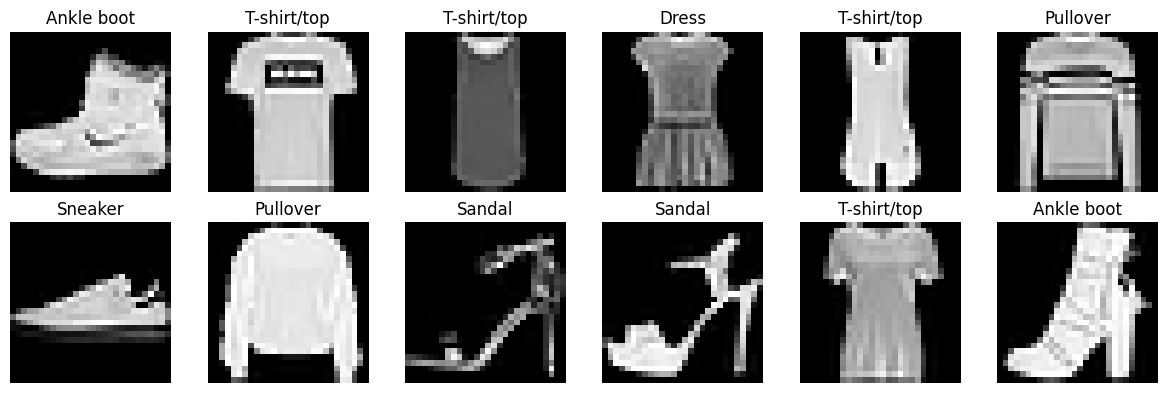

In [3]:
def plot_sample_images(images, labels, class_names, n=12):
    """
    Показывает несколько изображений из датасета.

    Аргументы:
        images: массив изображений формы (N, 28, 28).
        labels: числовые метки классов.
        class_names: список названий классов.
        n: количество изображений для показа.
    """
    plt.figure(figsize=(12, 4))

    for i in range(n):
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


plot_sample_images(x_train_raw, y_train, class_names)

## 3. Нормализация и формы данных

Для полносвязных автоэнкодеров изображение разворачивается в вектор длины `784`.

Для сверточного автоэнкодера изображение остается двумерным, но добавляется канал:

$$
28 \times 28 \rightarrow 28 \times 28 \times 1.
$$

In [4]:
x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 28 * 28)
x_test_flat = x_test.reshape(-1, 28 * 28)

x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]

print("Dense train:", x_train_flat.shape)
print("CNN train:", x_train_cnn.shape)

Dense train: (60000, 784)
CNN train: (60000, 28, 28, 1)


## 4. Общие функции визуализации и обучения

Чтобы блокнот был компактным, используем несколько небольших вспомогательных функций.

In [5]:
BATCH_SIZE = 256
EPOCHS = 12


def make_callbacks():
    """
    Создает callbacks для стабильного обучения.

    Возвращает:
        Список Keras callbacks.
    """
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def train_autoencoder(model, x_train, x_test, epochs=EPOCHS):
    """
    Обучает автоэнкодер восстанавливать собственный вход.

    Аргументы:
        model: скомпилированная Keras-модель.
        x_train: обучающие данные.
        x_test: тестовые данные для validation.
        epochs: максимальное число эпох.

    Возвращает:
        Объект History.
    """
    history = model.fit(
        x_train,
        x_train,
        validation_data=(x_test, x_test),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=make_callbacks(),
    )

    return history


def plot_history(history, title):
    """
    Строит график функции потерь.

    Аргументы:
        history: объект History после model.fit.
        title: заголовок графика.
    """
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.show()

In [6]:
def show_reconstructions(model, images, model_input, title, n=8):
    """
    Показывает исходные и восстановленные изображения.

    Аргументы:
        model: обученный автоэнкодер.
        images: исходные изображения формы (N, 28, 28).
        model_input: вход модели, соответствующий images.
        title: заголовок визуализации.
        n: количество примеров.
    """
    reconstructed = model.predict(model_input[:n], verbose=0)

    if reconstructed.ndim == 2:
        reconstructed = reconstructed.reshape(-1, 28, 28)
    else:
        reconstructed = reconstructed.squeeze(axis=-1)

    plt.figure(figsize=(14, 4))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title("Оригинал")
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i], cmap="gray")
        plt.title("Реконструкция")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Часть A. Простой полносвязный автоэнкодер

Самый простой автоэнкодер:

$$
784 \rightarrow 64 \rightarrow 784.
$$

Внутренний слой размерности `64` заставляет модель сжимать изображение.

In [7]:
def build_simple_dense_autoencoder(latent_dim=64):
    """
    Строит простой полносвязный автоэнкодер.

    Аргументы:
        latent_dim: размерность латентного пространства.

    Возвращает:
        autoencoder: модель вход -> реконструкция.
        encoder: модель вход -> латентный вектор.
    """
    input_image = keras.Input(shape=(784,), name="input_image")

    latent = layers.Dense(latent_dim, activation="relu", name="latent_vector")(input_image)
    reconstruction = layers.Dense(784, activation="sigmoid", name="reconstruction")(latent)

    autoencoder = keras.Model(input_image, reconstruction, name="simple_dense_autoencoder")
    encoder = keras.Model(input_image, latent, name="simple_dense_encoder")

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    return autoencoder, encoder


simple_autoencoder, simple_encoder = build_simple_dense_autoencoder(latent_dim=64)
simple_autoencoder.summary()

W0000 00:00:1780043871.371598    6124 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780043871.568672    6124 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "simple_dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12


I0000 00:00:1780043872.987920    6241 service.cc:153] XLA service 0x70c83802e6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780043872.987943    6241 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1780043872.998070    6241 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780043873.046661    6241 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1780043873.050546    6241 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_884__.5
I0000 00:00:1780043873.650821    6346 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 24 bytes spill stores, 24 bytes spill loads



107/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1040

I0000 00:00:1780043874.782798    6241 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


206/235 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0837

I0000 00:00:1780043875.180678    6241 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_884__.5


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0512 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 2/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0237 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 3/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181 - val_loss: 0.0162 - learning_rate: 0.0010
Epoch 4/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 5/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0132 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 6/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0122 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 7/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0114 - val_loss: 0.0112 - learning_rate: 0.0010
Epoch 8/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0109 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 9/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0104 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 10/12
235/235 ━

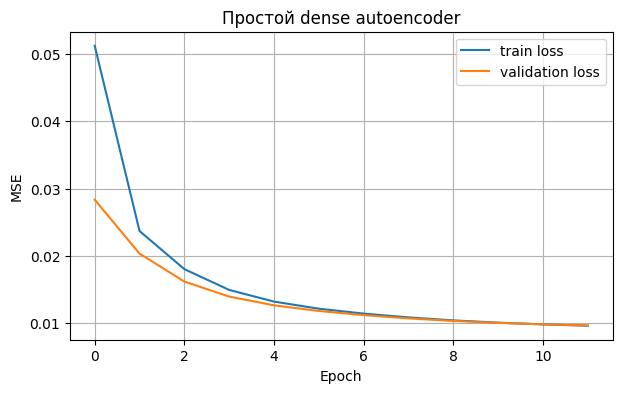

I0000 00:00:1780043882.274335    7630 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 4 bytes spill stores, 4 bytes spill loads



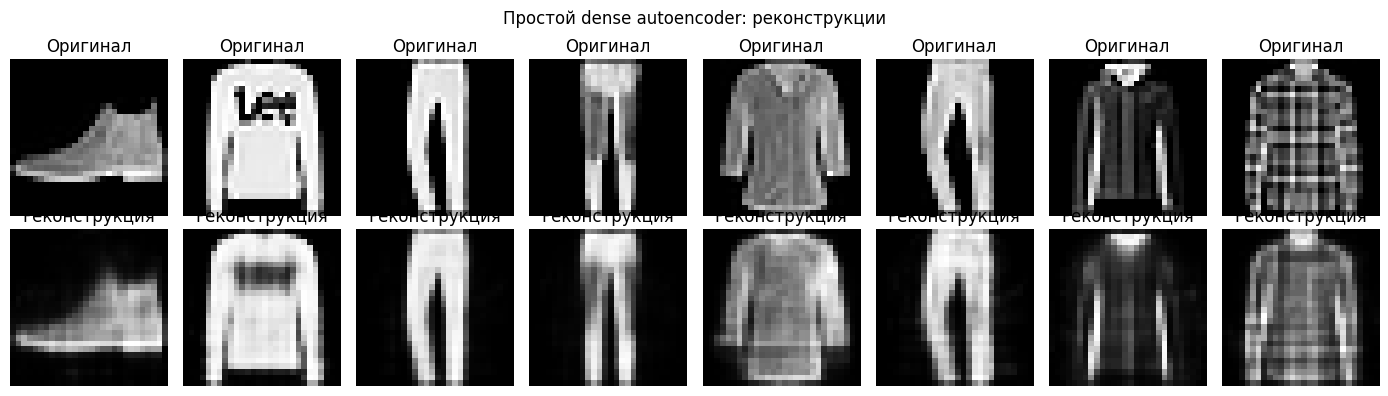

In [8]:
simple_history = train_autoencoder(simple_autoencoder, x_train_flat, x_test_flat)
plot_history(simple_history, "Простой dense autoencoder")
show_reconstructions(
    simple_autoencoder,
    images=x_test,
    model_input=x_test_flat,
    title="Простой dense autoencoder: реконструкции",
)

# Часть B. Deep dense autoencoder

Глубокий автоэнкодер использует несколько слоев в encoder и decoder:

$$
784 \rightarrow 256 \rightarrow 128 \rightarrow 64 \rightarrow 128 \rightarrow 256 \rightarrow 784.
$$

Глубина позволяет выучить более сложное нелинейное сжатие.

In [9]:
def build_deep_dense_autoencoder(latent_dim=64):
    """
    Строит глубокий полносвязный автоэнкодер.

    Аргументы:
        latent_dim: размерность центрального латентного слоя.

    Возвращает:
        autoencoder: модель вход -> реконструкция.
        encoder: модель вход -> латентный вектор.
    """
    input_image = keras.Input(shape=(784,), name="input_image")

    x = layers.Dense(256, activation="relu", name="encoder_dense_1")(input_image)
    x = layers.Dense(128, activation="relu", name="encoder_dense_2")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent_vector")(x)

    x = layers.Dense(128, activation="relu", name="decoder_dense_1")(latent)
    x = layers.Dense(256, activation="relu", name="decoder_dense_2")(x)
    reconstruction = layers.Dense(784, activation="sigmoid", name="reconstruction")(x)

    autoencoder = keras.Model(input_image, reconstruction, name="deep_dense_autoencoder")
    encoder = keras.Model(input_image, latent, name="deep_dense_encoder")

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    return autoencoder, encoder


deep_autoencoder, deep_encoder = build_deep_dense_autoencoder(latent_dim=64)
deep_autoencoder.summary()

Model: "deep_dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12


I0000 00:00:1780043883.883423    6243 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13474__.9
I0000 00:00:1780043884.080770    7732 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_36', 24 bytes spill stores, 24 bytes spill loads



205/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0734

I0000 00:00:1780043888.082219    6239 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13474__.9
I0000 00:00:1780043888.445058    7953 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_36', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1780043888.448196    7957 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_36', 4 bytes spill stores, 4 bytes spill loads



235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0423 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 2/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0201 - val_loss: 0.0180 - learning_rate: 0.0010
Epoch 3/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 4/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0156 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 5/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0143 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 6/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0136 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 7/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0129 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 8/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0123 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 9/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0118 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 10/12
235/235

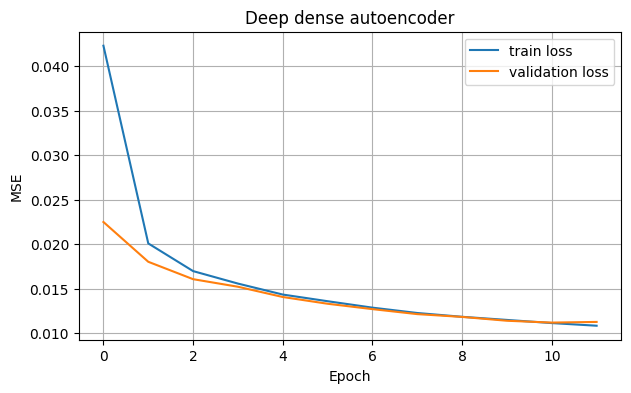

I0000 00:00:1780043899.822658    9268 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 4 bytes spill stores, 4 bytes spill loads



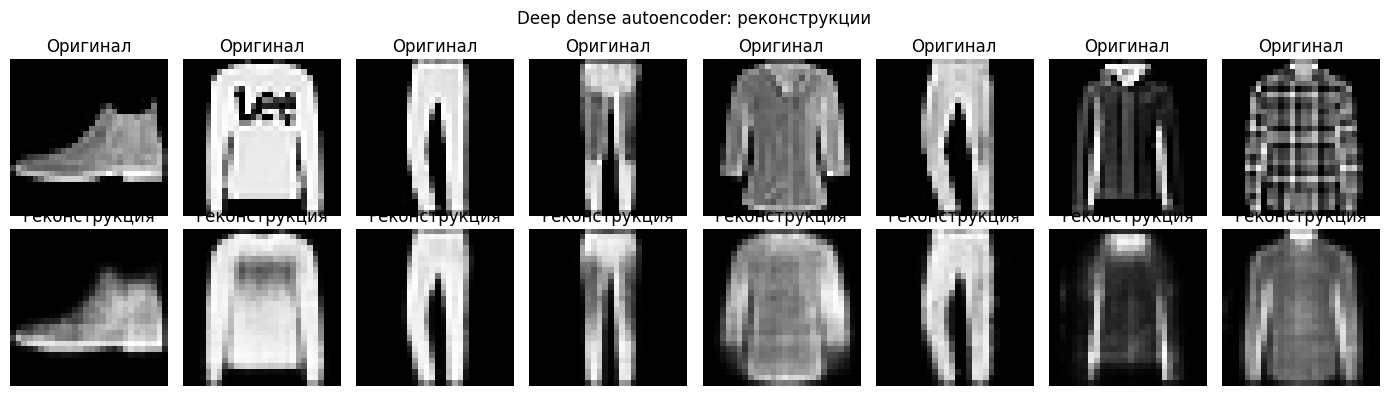

In [10]:
deep_history = train_autoencoder(deep_autoencoder, x_train_flat, x_test_flat)
plot_history(deep_history, "Deep dense autoencoder")
show_reconstructions(
    deep_autoencoder,
    images=x_test,
    model_input=x_test_flat,
    title="Deep dense autoencoder: реконструкции",
)

# Часть C. Сверточный автоэнкодер

Для изображений сверточные слои обычно подходят лучше, чем полносвязные:

- они используют локальную структуру изображения;
- имеют меньше параметров;
- лучше сохраняют пространственные признаки.

Encoder уменьшает пространственный размер, decoder восстанавливает изображение через `UpSampling2D`.

In [11]:
def build_convolutional_autoencoder():
    """
    Строит сверточный автоэнкодер для изображений 28 x 28 x 1.

    Возвращает:
        autoencoder: модель входное изображение -> восстановленное изображение.
        encoder: модель входное изображение -> сверточное латентное представление.
    """
    input_image = keras.Input(shape=(28, 28, 1), name="input_image")

    x = layers.Conv2D(32, 3, activation="relu", padding="same", name="encoder_conv_1")(input_image)
    x = layers.MaxPooling2D(2, padding="same", name="encoder_pool_1")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same", name="encoder_conv_2")(x)
    latent = layers.MaxPooling2D(2, padding="same", name="latent_feature_map")(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same", name="decoder_conv_1")(latent)
    x = layers.UpSampling2D(2, name="decoder_upsampling_1")(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same", name="decoder_conv_2")(x)
    x = layers.UpSampling2D(2, name="decoder_upsampling_2")(x)
    reconstruction = layers.Conv2D(1, 3, activation="sigmoid", padding="same", name="reconstruction")(x)

    autoencoder = keras.Model(input_image, reconstruction, name="convolutional_autoencoder")
    encoder = keras.Model(input_image, latent, name="convolutional_encoder")

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    return autoencoder, encoder


conv_autoencoder, conv_encoder = build_convolutional_autoencoder()
conv_autoencoder.summary()

Model: "convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool_1 (MaxPooling2D)   │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_feature_map              │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1 (Conv2D)         │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsampling_1            │ (None, 14, 14, 64)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2 (Conv2D)         │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsampling_2            │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0238 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 2/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0107 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 3/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0088 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 4/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0075 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 5/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0064 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 6/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 7/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0051 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 8/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0046 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 9/12
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0044 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 10/

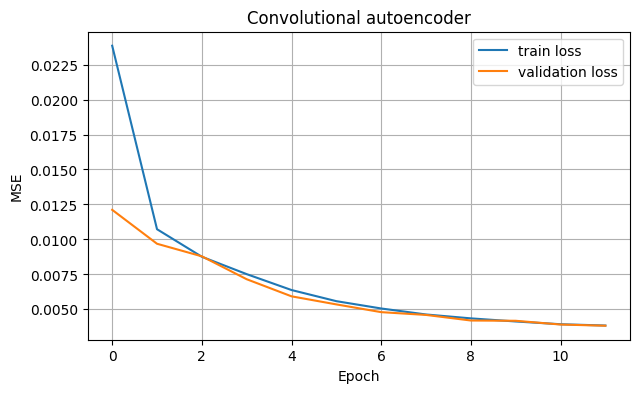

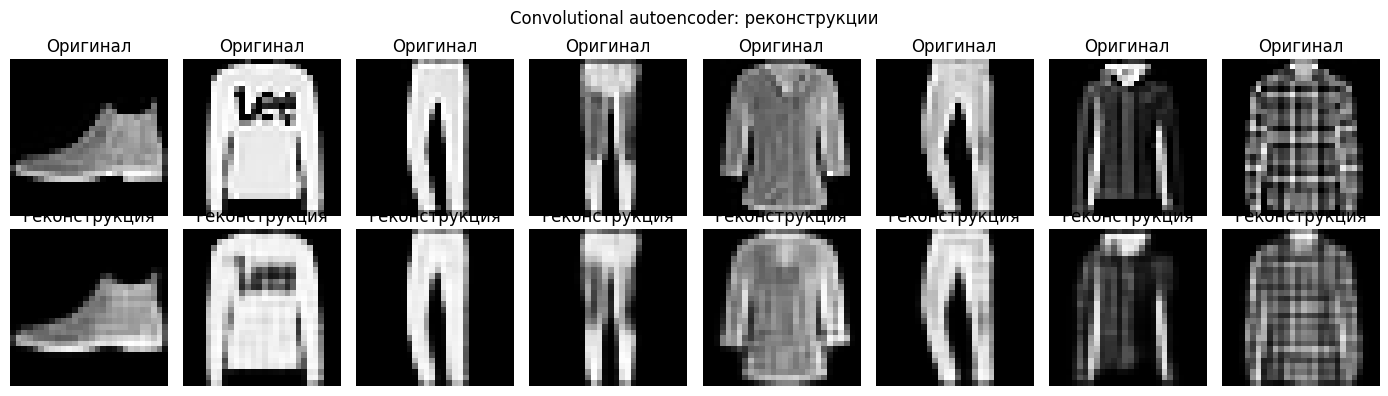

In [12]:
conv_history = train_autoencoder(conv_autoencoder, x_train_cnn, x_test_cnn)
plot_history(conv_history, "Convolutional autoencoder")
show_reconstructions(
    conv_autoencoder,
    images=x_test,
    model_input=x_test_cnn,
    title="Convolutional autoencoder: реконструкции",
)

## 5. Сравнение моделей

Сравним модели по минимальному `validation loss`.

Чем ниже MSE, тем ближе реконструкция к исходному изображению. Но визуальная проверка тоже важна: небольшое отличие в MSE не всегда означает заметно лучшую картинку.

In [13]:
def best_validation_loss(history):
    """
    Возвращает минимальное значение validation loss.

    Аргументы:
        history: объект History после обучения.

    Возвращает:
        Минимальный val_loss.
    """
    return float(np.min(history.history["val_loss"]))


comparison = pd.DataFrame(
    [
        {
            "model": "Simple dense",
            "best_val_mse": best_validation_loss(simple_history),
            "parameters": simple_autoencoder.count_params(),
        },
        {
            "model": "Deep dense",
            "best_val_mse": best_validation_loss(deep_history),
            "parameters": deep_autoencoder.count_params(),
        },
        {
            "model": "Convolutional",
            "best_val_mse": best_validation_loss(conv_history),
            "parameters": conv_autoencoder.count_params(),
        },
    ]
).sort_values("best_val_mse")

comparison

,model,best_val_mse,parameters
2,Convolutional,0.003830,74497
0,Simple dense,0.009693,101200
1,Deep dense,0.011194,484944


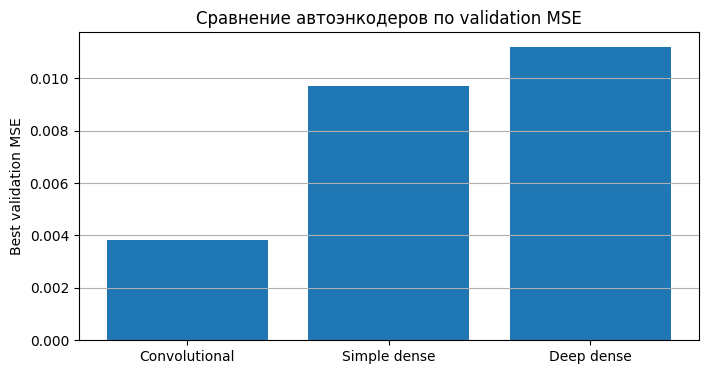

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(comparison["model"], comparison["best_val_mse"])
plt.title("Сравнение автоэнкодеров по validation MSE")
plt.ylabel("Best validation MSE")
plt.grid(axis="y")
plt.show()

## 6. Латентное пространство

Encoder можно использовать как способ получения признаков.

Ниже посмотрим распределение латентных векторов простого и глубокого dense autoencoder. Для визуализации возьмем первые две координаты латентного пространства. Это не полноценный метод снижения размерности, но для демонстрации идеи достаточно.

I0000 00:00:1780043920.263805    6239 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780043920.461118   11294 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 84 bytes spill stores, 84 bytes spill loads

I0000 00:00:1780043920.534493   11292 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 272 bytes spill stores, 272 bytes spill loads

I0000 00:00:1780043920.595844   11283 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 84 bytes spill stores, 84 bytes spill loads



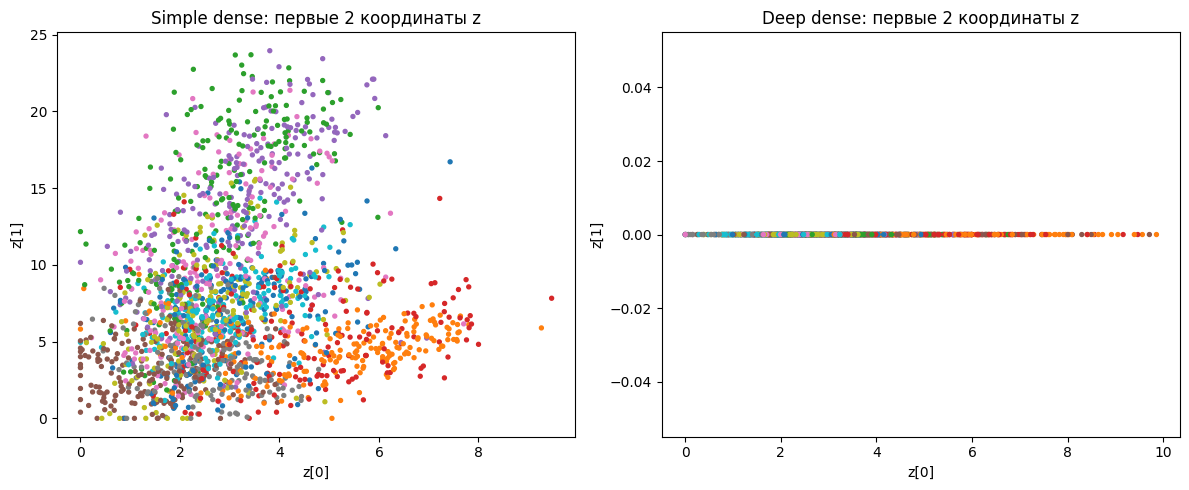

In [15]:
simple_latent = simple_encoder.predict(x_test_flat[:2000], verbose=0)
deep_latent = deep_encoder.predict(x_test_flat[:2000], verbose=0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(simple_latent[:, 0], simple_latent[:, 1], c=y_test[:2000], cmap="tab10", s=8)
plt.title("Simple dense: первые 2 координаты z")
plt.xlabel("z[0]")
plt.ylabel("z[1]")

plt.subplot(1, 2, 2)
plt.scatter(deep_latent[:, 0], deep_latent[:, 1], c=y_test[:2000], cmap="tab10", s=8)
plt.title("Deep dense: первые 2 координаты z")
plt.xlabel("z[0]")
plt.ylabel("z[1]")

plt.tight_layout()
plt.show()

## 7. Итоги

В этом блокноте мы:

- разобрали идею encoder-decoder архитектуры;
- обучили простой полносвязный автоэнкодер;
- обучили глубокий полносвязный автоэнкодер;
- обучили сверточный автоэнкодер;
- сравнили качество реконструкции по MSE;
- посмотрели, как выглядят восстановленные изображения.

Практический вывод:

- полносвязный автоэнкодер полезен для объяснения идеи сжатия;
- глубокий dense autoencoder может выучить более сложные признаки;
- сверточный autoencoder обычно лучше подходит для изображений, потому что сохраняет пространственную структуру.